<a href="https://colab.research.google.com/github/SarahSAH02/Dat255_prosjekt/blob/main/resnet18_modell_ferdig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (4).zip"
extract_path = "/content/chexpert"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
done!



**IMPORTS**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

**DATASET & PREPROCRSSING**

We are using the Chexpert dataset with 14 labels. Missing values (NaN) and uncertain labels (-1) are mapped to 0.

In [4]:


label_values = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]


train_df = pd.read_csv(os.path.join(extract_path, "train.csv"))
valid_df = pd.read_csv(os.path.join(extract_path, "valid.csv"))


train_df['Path'] = train_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
valid_df['Path'] = valid_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)

train_df[label_values] = train_df[label_values].fillna(0).replace(-1, 0)
valid_df[label_values] = valid_df[label_values].fillna(0).replace(-1, 0)

train_df = train_df[['Path'] + label_values]
valid_df = valid_df[['Path'] + label_values]



print(train_df.head())

                                          Path  Atelectasis  Cardiomegaly  \
0  train/patient00001/study1/view1_frontal.jpg          0.0           0.0   
1  train/patient00002/study2/view1_frontal.jpg          0.0           0.0   
2  train/patient00002/study1/view1_frontal.jpg          0.0           0.0   
3  train/patient00002/study1/view2_lateral.jpg          0.0           0.0   
4  train/patient00003/study1/view1_frontal.jpg          0.0           0.0   

   Consolidation  Edema  Enlarged Cardiomediastinum  Fracture  Lung Lesion  \
0            0.0    0.0                         0.0       0.0          0.0   
1            0.0    0.0                         0.0       1.0          0.0   
2            0.0    0.0                         0.0       1.0          0.0   
3            0.0    0.0                         0.0       1.0          0.0   
4            0.0    1.0                         0.0       0.0          0.0   

   Lung Opacity  No Finding  Pleural Effusion  Pleural Other  Pneumo

**DATA ANALYSIS**

Analyzing the dataset to understand label distribution and class imbalance, which is common in medical dataset

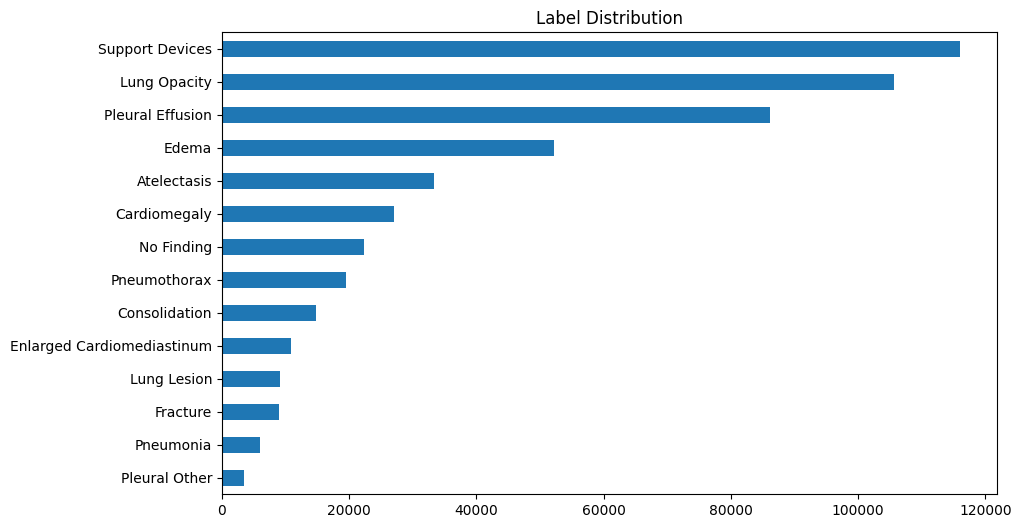

In [5]:
label_counts = train_df[label_values].sum().sort_values()

plt.figure(figsize=(10,6))
label_counts.plot(kind='barh')
plt.title("Label Distribution")
plt.show()

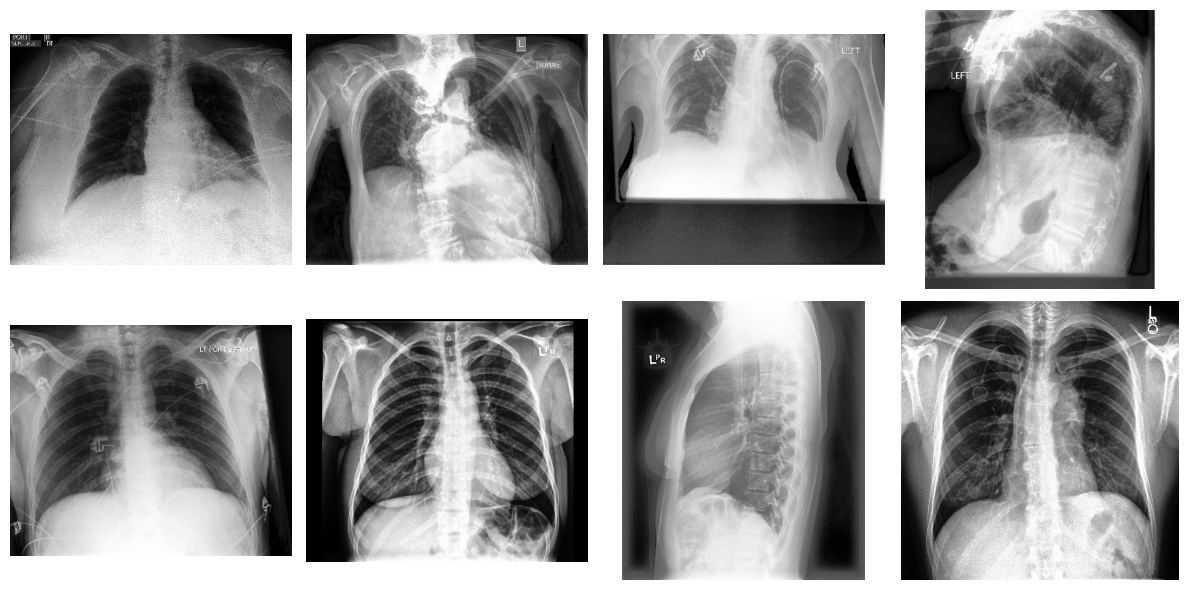

In [6]:
fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flatten()):

    full_img_path = os.path.join(extract_path, train_df.iloc[i]['Path'])
    img = Image.open(full_img_path).convert("RGB")
    ax.imshow(img, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()

**DATA TRANSFORM**

Using data augmentation and resizing images to improve generalization and reduce overfitting.

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**DATASET**




In [8]:
class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_img_path = os.path.join(extract_path, row['Path'])
        img = Image.open(full_img_path).convert("RGB")
        labels = row[1:].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(labels)

**DATALOADER**

Dataloader are used to load data in batches

In [9]:
train_dataset = CheXpertDataset(train_df, train_transform)
valid_dataset = CheXpertDataset(valid_df, valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

**MODEL ARCHITECTURES**

Resnet18, ---- , a custum CNN

In [10]:
def get_resnet():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 14)
    return model



    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32*56*56, 14)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

**LOSS & OPTIMIZIER**

Binary Cross Entropy with logits is used for multi-label classification.

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.ones(14).to(device)

L_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(device)

cuda


In [12]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


In [13]:
img, label = train_dataset[0]
print(img.shape, label.shape)

torch.Size([3, 224, 224]) torch.Size([14])


In [14]:
print(train_df.iloc[0]['Path'])
print(os.path.exists(os.path.join(extract_path, train_df.iloc[0]['Path'])))

train/patient00001/study1/view1_frontal.jpg
True


**Training of models**

In [15]:
print("Train size:", len(train_df))
print("Valid size:", len(valid_df))

Train size: 223414
Valid size: 234


Models are trained using Adam optimizer with weight decay.

In [16]:
def train_model(model, epochs=3):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=2
    )

    train_losses = []
    val_losses = []

    best_f1 = 0

    for epoch in range(epochs):


        model.train()
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = L_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch {epoch+1} Batch {i}/{len(train_loader)} Loss {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)



        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in valid_loader: # Changed val_loader to valid_loader
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = L_func(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(valid_loader) # Changed val_loader to valid_loader
        val_losses.append(val_loss)

        scheduler.step(val_loss)



        print("\nEvaluation:")
        f1, auc = evaluate(model)


        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"F1 Score:   {f1:.4f}")
        print(f"AUC:        {auc:.4f}")



        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "best_model.pth")
            print("Beste modell lagret!")

    return train_losses, val_losses

**EVALUATION**

Model performance is evaluated using Macro F1-score and ROC-AUC. Threshold tuning is applied to improve classification performance.

In [17]:
def get_preds(model):
    model.eval()
    preds,targets=[],[]
    with torch.no_grad():
        for images,labels in valid_loader:
            images=images.to(device)
            outputs=torch.sigmoid(model(images)).cpu().numpy()
            preds.append(outputs)
            targets.append(labels.numpy())
    return np.vstack(preds), np.vstack(targets)

In [18]:
def find_thresholds(preds,targets):
    thresholds=[]
    for i in range(14):
        best_t,best_f1=0.5,0
        for t in np.arange(0.1,0.9,0.05):
            f1=f1_score(targets[:,i], (preds[:,i]>t).astype(int))
            if f1>best_f1:
                best_f1, best_t = f1,t
        thresholds.append(best_t)
    return thresholds

In [19]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

def evaluate(model):
    preds, targets = get_preds(model)

    thresholds = []

    for i in range(14):
        best_t = 0.5
        best_f1 = 0

        for t in np.arange(0.1, 0.9, 0.05):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(targets[:, i], pred_bin, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    preds_bin = np.zeros_like(preds)

    for i in range(14):
        preds_bin[:, i] = (preds[:, i] > thresholds[i]).astype(int)

    f1 = f1_score(targets, preds_bin, average="macro", zero_division=0)

    valid_auc = []
    for i in range(14):
        if len(np.unique(targets[:, i])) > 1:
            valid_auc.append(
                roc_auc_score(targets[:, i], preds[:, i])
            )

    auc = np.mean(valid_auc)

    print("Macro F1:", f1)
    print("Mean AUC:", auc)

    return f1, auc

**RUN BASELINE**

In [20]:
#Trener modelle (lagrer beste automatisk)
model = get_resnet()
train_model(model, epochs=3)

# Laster beste modell
model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

print("Beste modell lastet ned!")

#Evaluerer beste modell
evaluate(model)

#Lagrer final modell
torch.save(model.state_dict(), "resnet18_final.pth")
print("Final modell lagret!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Epoch 1 Batch 0/6982 Loss 0.7254
Epoch 1 Batch 50/6982 Loss 0.3957
Epoch 1 Batch 100/6982 Loss 0.3050
Epoch 1 Batch 150/6982 Loss 0.3420
Epoch 1 Batch 200/6982 Loss 0.3577
Epoch 1 Batch 250/6982 Loss 0.3536
Epoch 1 Batch 300/6982 Loss 0.3319
Epoch 1 Batch 350/6982 Loss 0.3210
Epoch 1 Batch 400/6982 Loss 0.3227
Epoch 1 Batch 450/6982 Loss 0.3192
Epoch 1 Batch 500/6982 Loss 0.3243
Epoch 1 Batch 550/6982 Loss 0.2996
Epoch 1 Batch 600/6982 Loss 0.3441
Epoch 1 Batch 650/6982 Loss 0.3155
Epoch 1 Batch 700/6982 Loss 0.3111
Epoch 1 Batch 750/6982 Loss 0.3076
Epoch 1 Batch 800/6982 Loss 0.3131
Epoch 1 Batch 850/6982 Loss 0.3522
Epoch 1 Batch 900/6982 Loss 0.3389
Epoch 1 Batch 950/6982 Loss 0.2930
Epoch 1 Batch 1000/6982 Loss 0.3285
Epoch 1 Batch 1050/6982 Loss 0.3004
Epoch 1 Batch 1100/6982 Loss 0.3132
Epoch 1 Batch 1150/6982 Loss 0.3772
Epoch 1 Batch 1200/6982 Loss 0.3063
Epoch 1 Batch 1250/6982 Loss 0.3001
Epoch 1 Batch 1300/6982 Loss 0.3015
Epoch 1 Batch 1350/6982 Loss 0.3663
Epoch 1 Batch 1

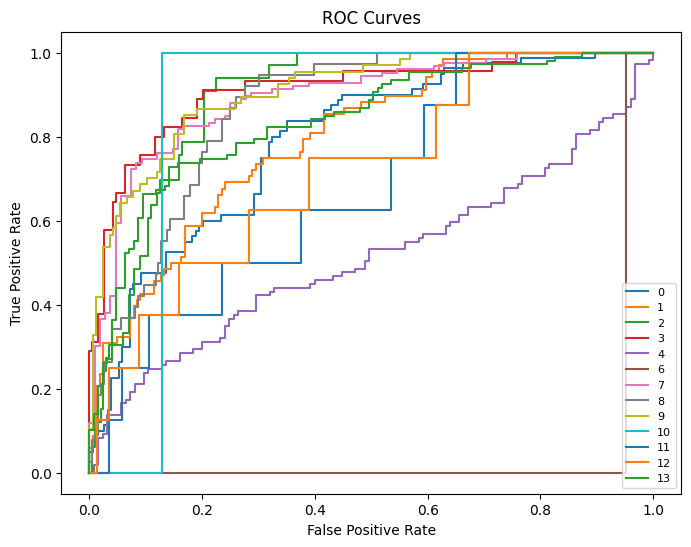

In [21]:
from sklearn.metrics import roc_curve

preds, targets = get_preds(model)

plt.figure(figsize=(8,6))

for i in range(14):
    if len(np.unique(targets[:, i])) > 1:
        fpr, tpr, _ = roc_curve(targets[:, i], preds[:, i])
        plt.plot(fpr, tpr, label=f"{i}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.show()

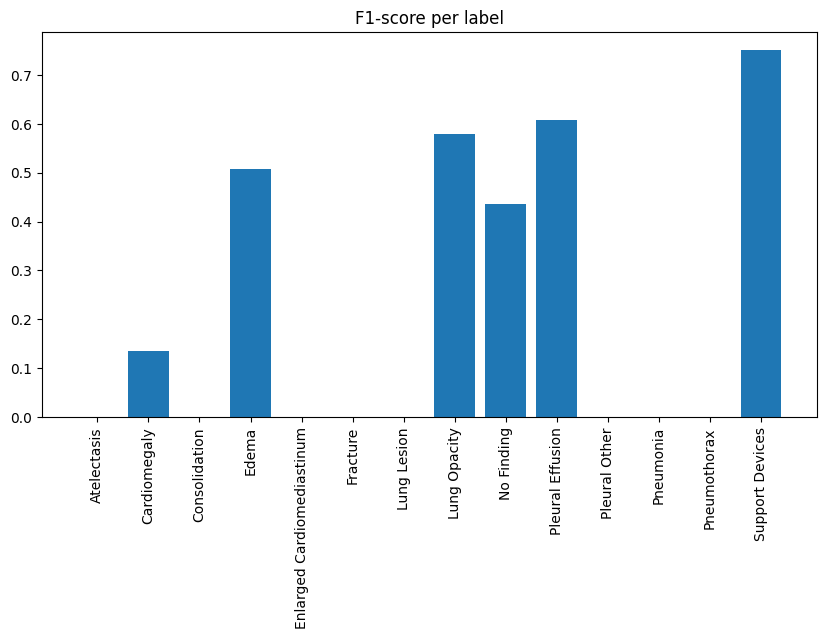

In [22]:
f1_scores = []

for i in range(14):
    pred_bin = (preds[:, i] > 0.5).astype(int)
    f1 = f1_score(targets[:, i], pred_bin, zero_division=0)
    f1_scores.append(f1)

plt.figure(figsize=(10,5))
plt.bar(range(14), f1_scores)
plt.xticks(range(14), label_values, rotation=90)
plt.title("F1-score per label")
plt.show()

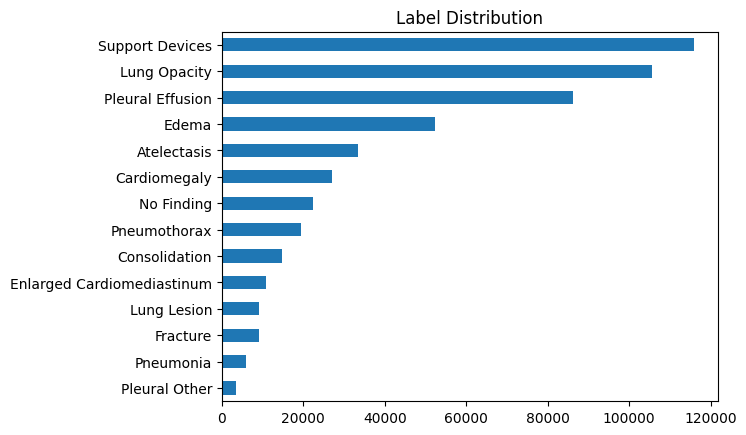

In [23]:
train_df[label_values].sum().sort_values().plot(kind='barh')
plt.title("Label Distribution")
plt.show()

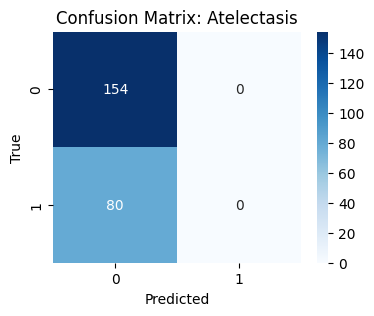

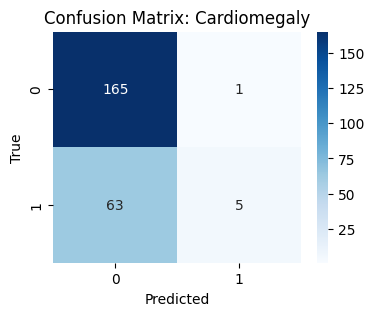

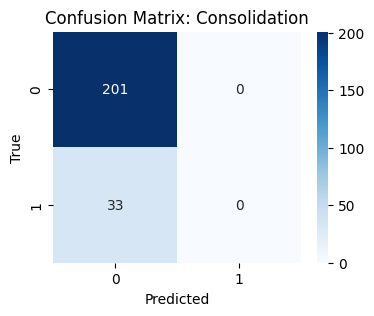

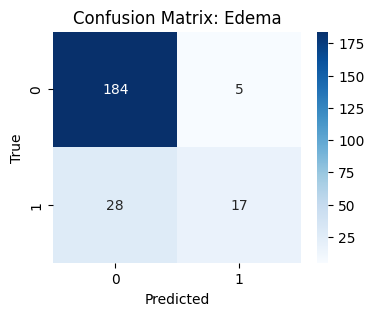

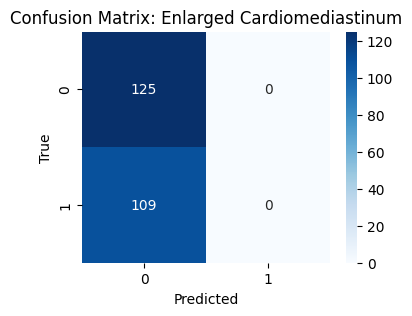

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


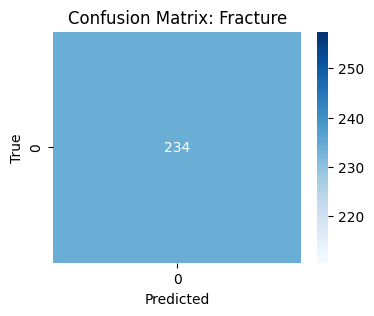

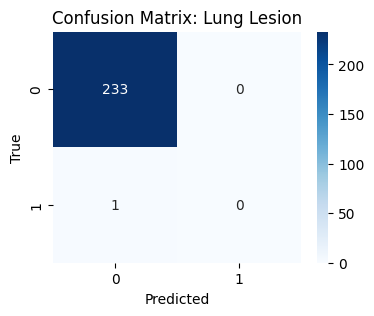

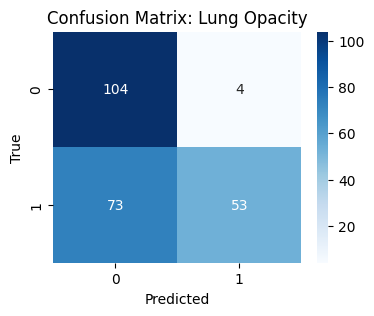

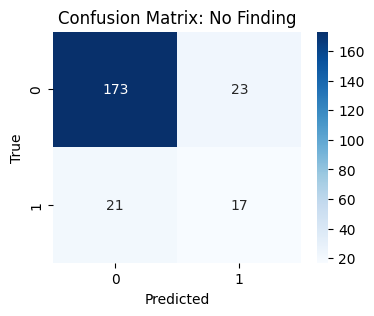

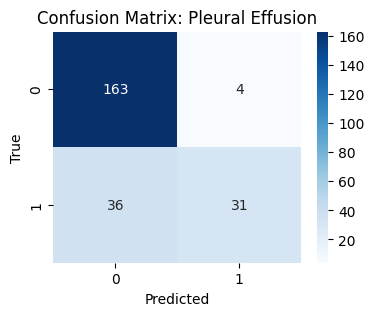

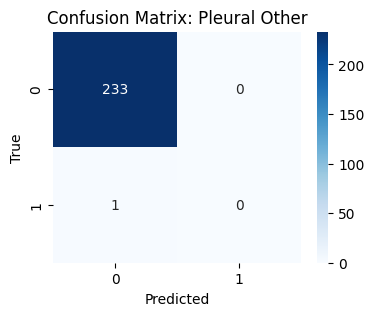

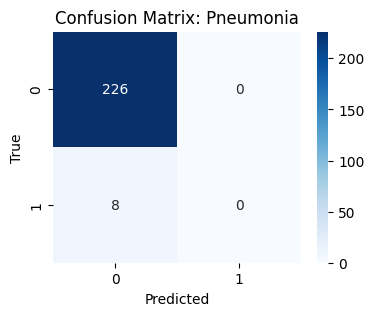

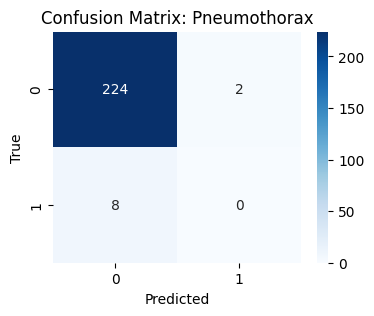

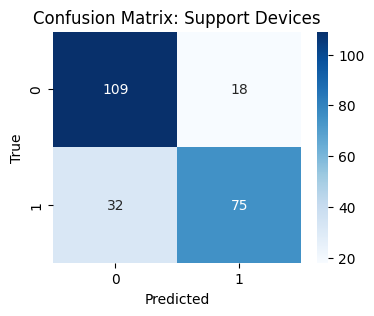

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds, targets = get_preds(model)

preds_bin = (preds > 0.5).astype(int)

for i in range(14):
    cm = confusion_matrix(targets[:, i], preds_bin[:, i])

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {label_values[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

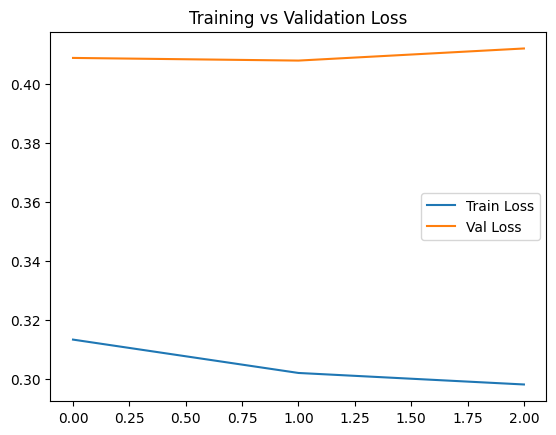

In [28]:
import matplotlib.pyplot as plt

train_losses = [0.3133, 0.3020, 0.2981]
val_losses   = [0.4087, 0.4078, 0.4119]

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [26]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_gradcam(model, image_tensor, target_layer):
    model.eval()

    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, input, output):
        activations.append(output)

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(image_tensor)
    target_class = 0
    target = output[0][target_class]

    model.zero_grad()
    target.backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations[0].cpu().data.numpy()[0]

    weights = np.mean(grads, axis=(1,2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)

    handle_f.remove()
    handle_b.remove()

    return cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


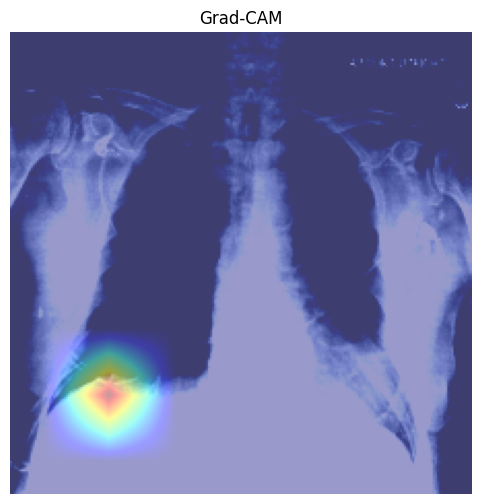

In [27]:
img, label = valid_dataset[0]

input_tensor = img.unsqueeze(0).to(device)

cam = generate_gradcam(model, input_tensor, model.layer4[-1])

img_np = img.permute(1,2,0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(img_np, alpha=0.6)
plt.imshow(cam, cmap='jet', alpha=0.4)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()